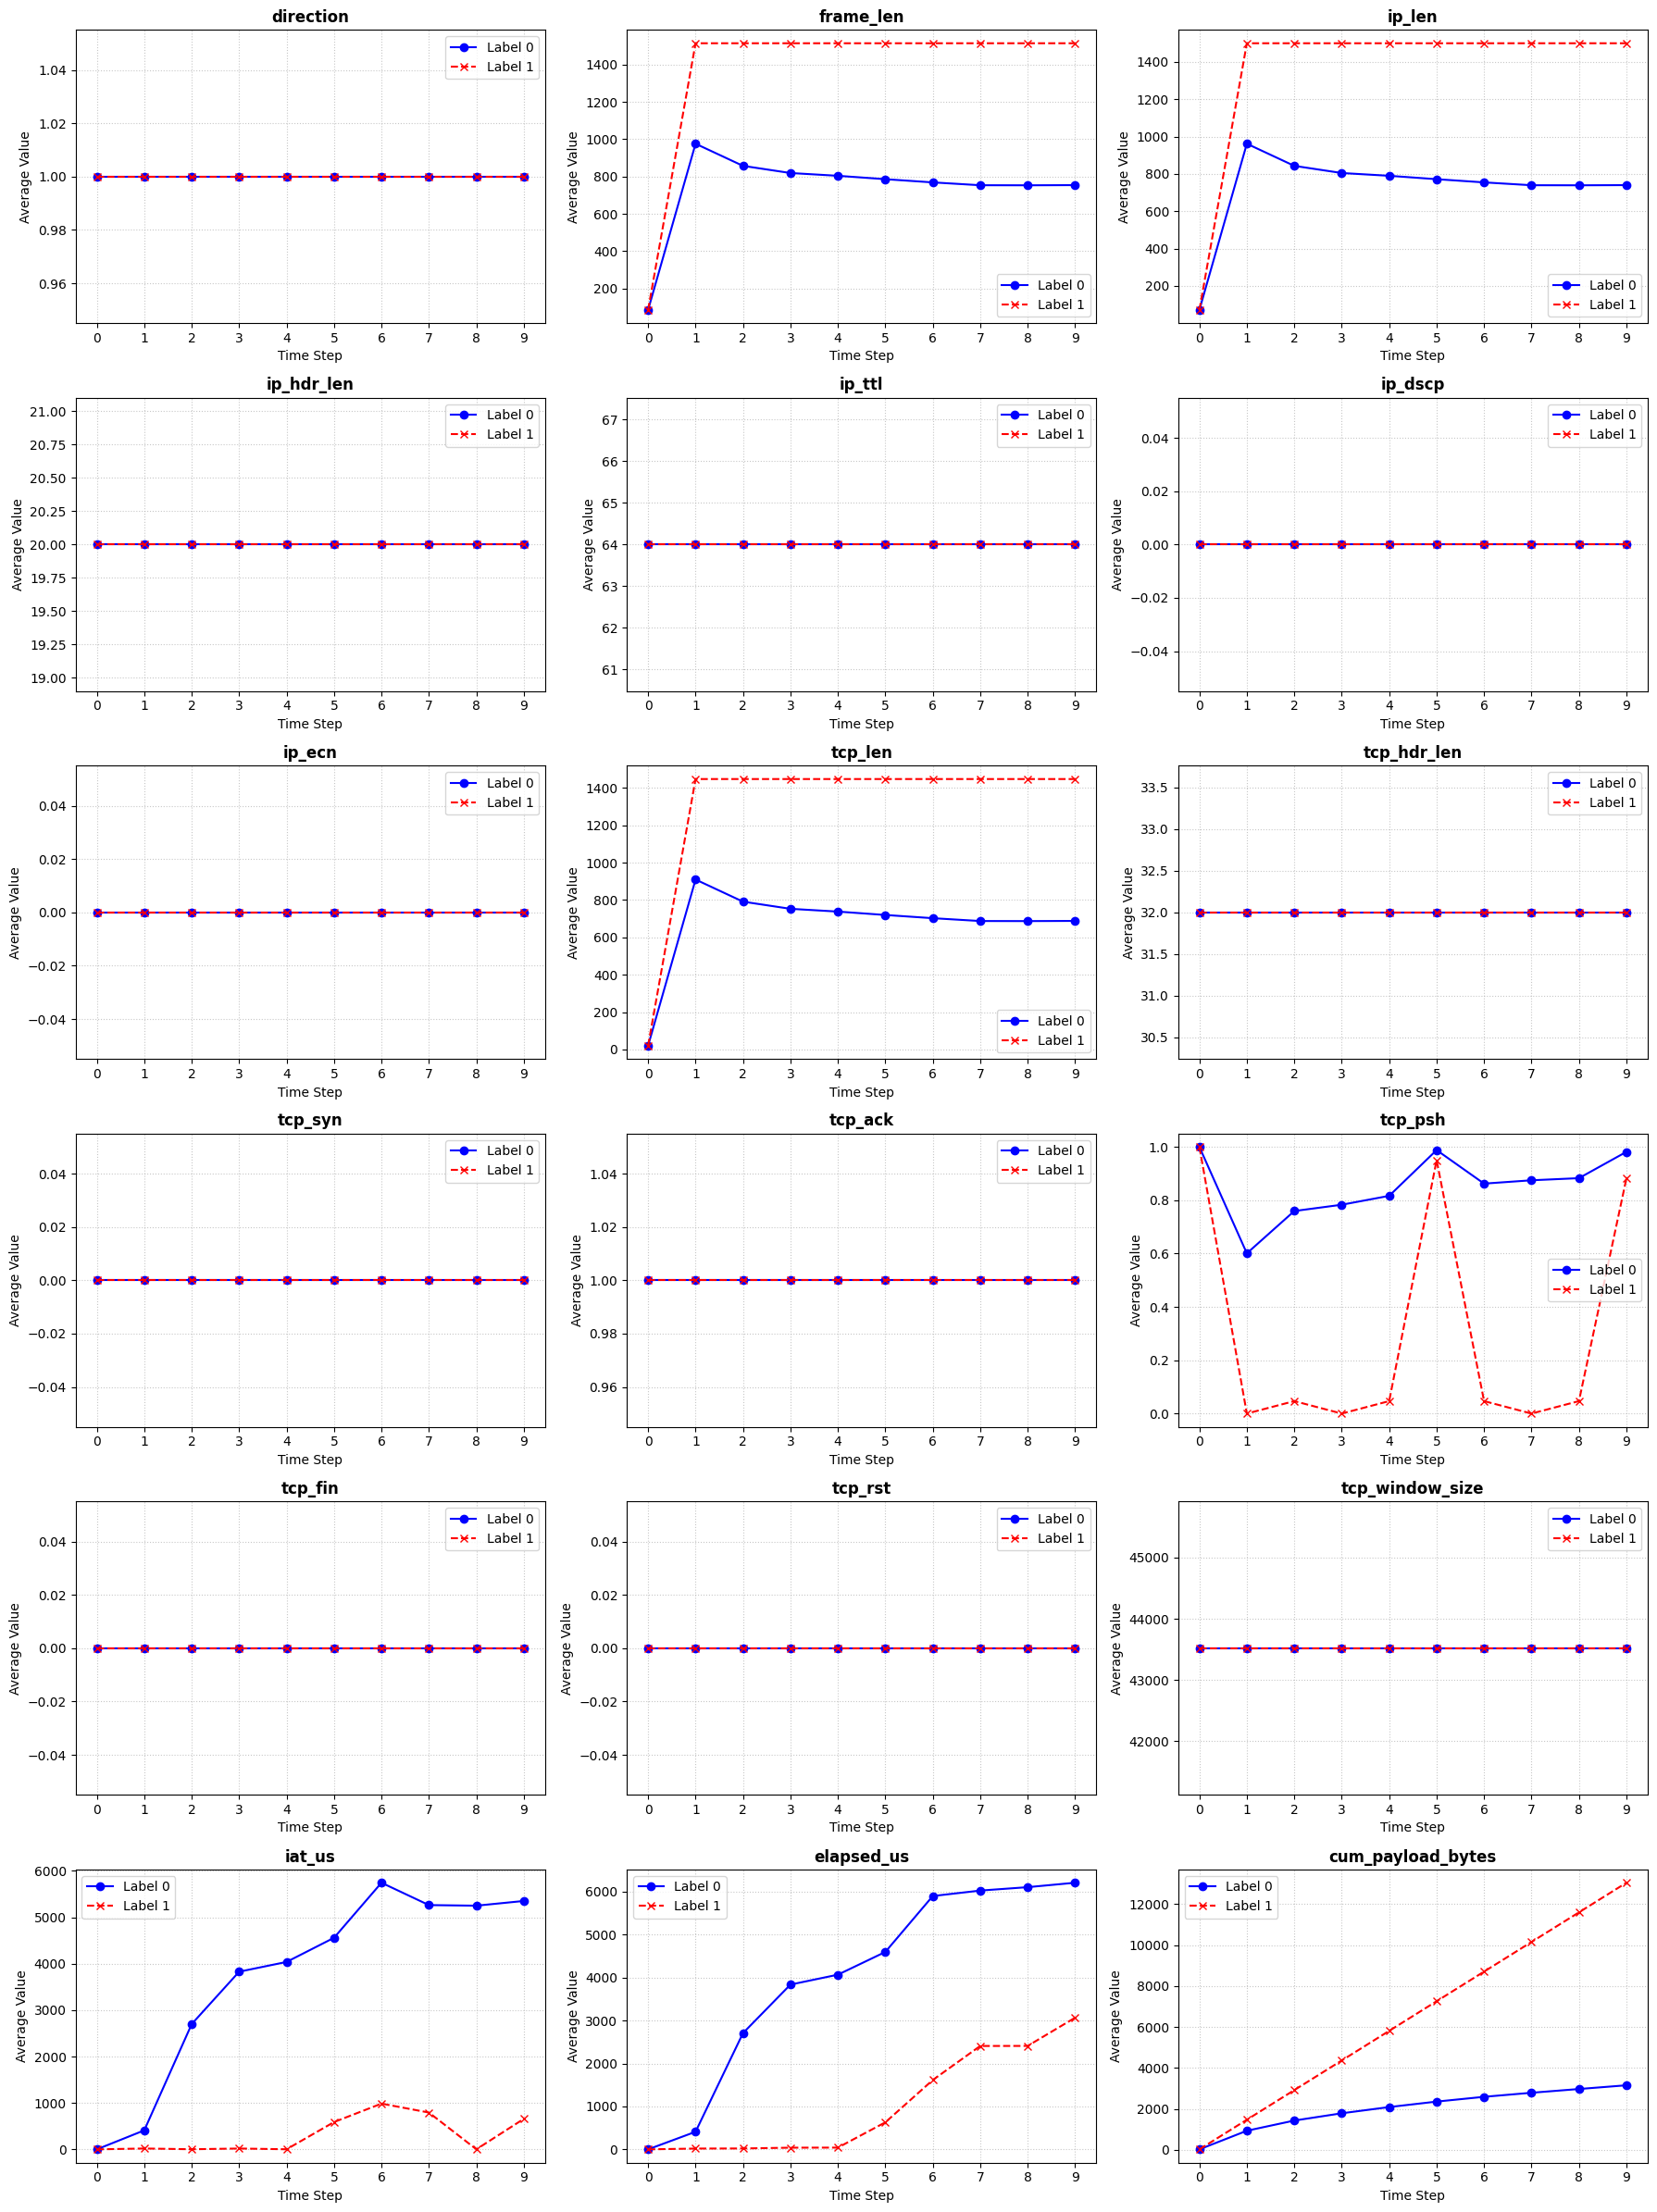

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

def visualize_flow_features(jsonl_file_path, target_seq_len=10):
    data_label_0 = []
    data_label_1 = []
    feature_names = []

    # 1. JSONL 파일 읽기 및 결측치 NaN 처리
    with open(jsonl_file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if not line.strip():
                continue
            
            record = json.loads(line)
            
            if i == 0:
                feature_names = record['feature_names']
                num_features = len(feature_names)
            
            x = record['x']  # 형태: (현재_타임스텝_수, 18)
            label = record['label']
            
            x_arr = np.array(x, dtype=float) # NaN을 넣기 위해 float 타입으로 변환
            current_len = x_arr.shape[0]
            
            # target_seq_len(10) 크기의 기본 NaN 배열 생성
            x_fixed = np.full((target_seq_len, num_features), np.nan)
            
            if current_len < target_seq_len:
                # 데이터가 있는 타임스텝만 기존 값으로 채우고, 나머지는 NaN으로 유지
                x_fixed[:current_len, :] = x_arr
            else:
                # 10개보다 많으면 10개까지만 잘라서 할당
                x_fixed[:, :] = x_arr[:target_seq_len, :]

            if label == 0:
                data_label_0.append(x_fixed)
            elif label == 1:
                data_label_1.append(x_fixed)
                
    # 2. Numpy 배열로 변환 (형태: 샘플 수, 10, 18)
    arr_0 = np.array(data_label_0) if data_label_0 else np.empty((0, target_seq_len, num_features))
    arr_1 = np.array(data_label_1) if data_label_1 else np.empty((0, target_seq_len, num_features))

    # 3. np.nanmean을 사용하여 NaN을 '완전 제외'하고 존재하는 값들로만 평균 계산
    mean_0 = np.nanmean(arr_0, axis=0) if len(arr_0) > 0 else np.zeros((target_seq_len, num_features))
    mean_1 = np.nanmean(arr_1, axis=0) if len(arr_1) > 0 else np.zeros((target_seq_len, num_features))

    # 4. 시각화 (18개의 그래프를 6행 3열로 배치)
    fig, axes = plt.subplots(6, 3, figsize=(18, 24))
    axes = axes.flatten()
    time_steps = np.arange(target_seq_len)

    for i in range(num_features):
        ax = axes[i]
        
        # Label 0 그래프 (파란색 실선)
        if len(arr_0) > 0:
            ax.plot(time_steps, mean_0[:, i], label='Label 0', marker='o', color='blue', linestyle='-')
            
        # Label 1 그래프 (빨간색 점선)
        if len(arr_1) > 0:
            ax.plot(time_steps, mean_1[:, i], label='Label 1', marker='x', color='red', linestyle='--')
            
        ax.set_title(feature_names[i], fontsize=12, fontweight='bold')
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Average Value')
        ax.set_xticks(time_steps)
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

# 실행
visualize_flow_features('elephant_dst_to_src/vl2/seq10/dataset.jsonl', target_seq_len=10)
